In [1]:
import os
import random
import matplotlib.pyplot as plt
from PIL import Image
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import numpy as np
from sklearn.metrics import classification_report
from tensorflow.keras.models import load_model
import warnings

In [2]:
warnings.filterwarnings("ignore")

<h1>Loading Data</h1>

Classes: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']


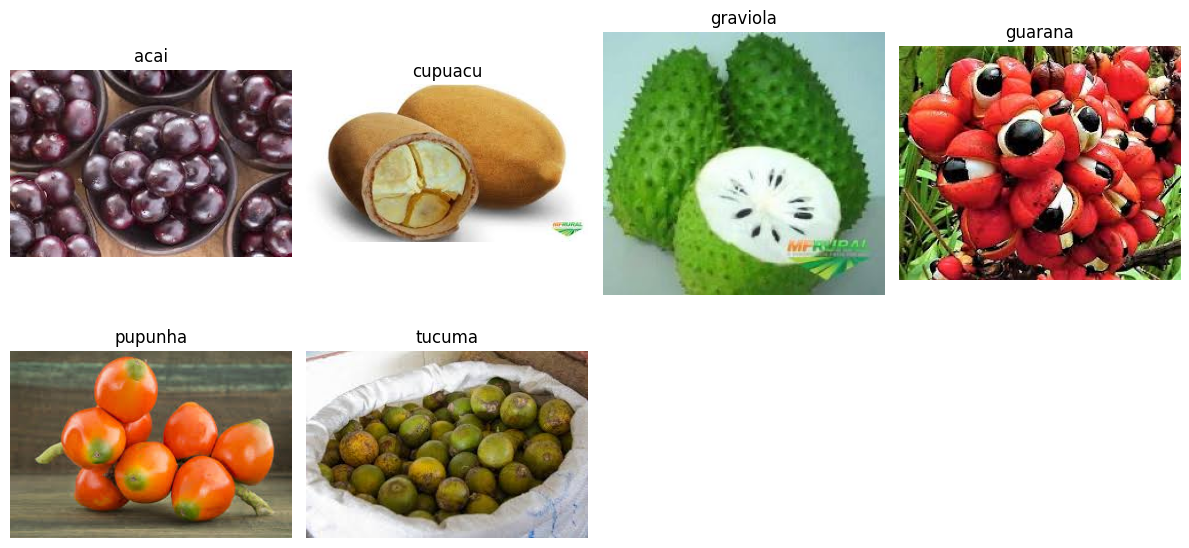

In [3]:
train_dir = "FruitinAmazon/train"

# Get class names
classes = os.listdir(train_dir)
print("Classes:", classes)

# Select one random image from each class
images = []
titles = []

for cls in classes:
    cls_path = os.path.join(train_dir, cls)
    img_name = random.choice(os.listdir(cls_path))
    img_path = os.path.join(cls_path, img_name)

    images.append(Image.open(img_path))
    titles.append(cls)

# Plot in grid (2 rows)
plt.figure(figsize=(12, 6))
for i in range(len(images)):
    plt.subplot(2, (len(images)//2)+1, i+1)
    plt.imshow(images[i])
    plt.title(titles[i])
    plt.axis('off')

plt.tight_layout()
plt.show()

In [4]:
img_height = 128
img_width = 128
batch_size = 32
validation_split = 0.2

# Normalize layer
rescale = tf.keras.layers.Rescaling(1./255)

# Train dataset
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    batch_size=batch_size,
    shuffle=True,
    validation_split=validation_split,
    subset='training',
    seed=123
)

train_ds = train_ds.map(lambda x, y: (rescale(x), y))

# Validation dataset
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    batch_size=batch_size,
    shuffle=False,
    validation_split=validation_split,
    subset='validation',
    seed=123
)

val_ds = val_ds.map(lambda x, y: (rescale(x), y))

Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.


In [5]:
num_classes = len(classes)

model = models.Sequential([
    # Conv Block 1
    layers.Conv2D(32, (3,3), padding='same', activation='relu', input_shape=(128,128,3)),
    layers.MaxPooling2D((2,2)),

    # Conv Block 2
    layers.Conv2D(32, (3,3), padding='same', activation='relu'),
    layers.MaxPooling2D((2,2)),

    # Flatten
    layers.Flatten(),

    # Fully Connected
    layers.Dense(64, activation='relu'),
    layers.Dense(128, activation='relu'),

    # Output
    layers.Dense(num_classes, activation='softmax')
])

In [6]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 128, 128, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 64, 64, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 64, 64, 32)          │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 32, 32, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 32768)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 64)                  │       2,097,216 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 128)                 │           8,320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 6)                   │             774 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,116,454 (8.07 MB)

 Trainable params: 2,116,454 (8.07 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:
checkpoint = ModelCheckpoint(
    "best_model.h5",
    monitor='val_loss',
    save_best_only=True
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=250,
    callbacks=[checkpoint, early_stop]
)

Epoch 1/250
2/3 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.1406 - loss: 1.8604

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 188ms/step - accuracy: 0.1528 - loss: 1.9475 - val_accuracy: 0.6667 - val_loss: 1.5405
Epoch 2/250
2/3 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.3516 - loss: 1.6681

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step - accuracy: 0.3472 - loss: 1.6691 - val_accuracy: 0.6667 - val_loss: 1.4732
Epoch 3/250
2/3 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.2969 - loss: 1.5560

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step - accuracy: 0.3750 - loss: 1.4989 - val_accuracy: 0.4444 - val_loss: 1.4333
Epoch 4/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 0.5972 - loss: 1.2971 - val_accuracy: 0.2222 - val_loss: 1.5809
Epoch 5/250
2/3 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.5547 - loss: 1.1255

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step - accuracy: 0.6250 - loss: 1.1063 - val_accuracy: 0.3333 - val_loss: 1.2816
Epoch 6/250
2/3 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.7266 - loss: 0.9215

...

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step - accuracy: 0.8472 - loss: 0.6324 - val_accuracy: 0.6667 - val_loss: 0.8901
Epoch 9/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.9410 - loss: 0.4061

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - accuracy: 0.9167 - loss: 0.4524 - val_accuracy: 0.8889 - val_loss: 0.7497
Epoch 10/250
2/3 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 1.0000 - loss: 0.2833

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step - accuracy: 1.0000 - loss: 0.2653 - val_accuracy: 0.7222 - val_loss: 0.6888
Epoch 11/250
2/3 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.9609 - loss: 0.2546

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step - accuracy: 0.9583 - loss: 0.2342 - val_accuracy: 0.8333 - val_loss: 0.5033
Epoch 12/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - accuracy: 1.0000 - loss: 0.1024 - val_accuracy: 0.8889 - val_loss: 0.5548
Epoch 13/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.9583 - loss: 0.1660 - val_accuracy: 0.8333 - val_loss: 0.6358
Epoch 14/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 1.0000 - loss: 0.0695 - val_accuracy: 0.8333 - val_loss: 0.5038
Epoch 15/250
2/3 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.9766 - loss: 0.0709

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step - accuracy: 0.9861 - loss: 0.0738 - val_accuracy: 0.8889 - val_loss: 0.2304
Epoch 16/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 1.0000 - loss: 0.0347 - val_accuracy: 0.8889 - val_loss: 0.3164
Epoch 17/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - accuracy: 0.9861 - loss: 0.0423 - val_accuracy: 0.8889 - val_loss: 0.2352
Epoch 18/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - accuracy: 1.0000 - loss: 0.0247 - val_accuracy: 0.8889 - val_loss: 0.3992
Epoch 19/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - accuracy: 1.0000 - loss: 0.0112 - val_accuracy: 0.8889 - val_loss: 0.5052
Epoch 20/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 1.0000 - loss: 0.0173 - val_accuracy: 0.8889 - val_loss: 0.4935
Epoch 21/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 1.0000 - loss: 0.0177 - val_accuracy: 0.8889 - val_loss: 0.3772
Epoch 22/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - accuracy: 1.0000 - loss: 0.0048 - val_accuracy: 0.8889 - val_loss: 0.3

In [8]:
test_dir = "FruitinAmazon/test"

test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    image_size=(128,128),
    batch_size=32,
    shuffle=False
)

test_ds = test_ds.map(lambda x, y: (rescale(x), y))

loss, acc = model.evaluate(test_ds)
print("Test Accuracy:", acc)

Found 30 files belonging to 6 classes.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - accuracy: 0.6667 - loss: 1.0123
Test Accuracy: 0.6666666865348816


In [9]:
# Save
model.save("final_model.h5")

# Load
loaded_model = load_model("final_model.h5")

# Re-evaluate
loaded_model.evaluate(test_ds)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 241ms/step - accuracy: 0.6667 - loss: 1.0123


[1.012311577796936, 0.6666666865348816]

In [10]:
y_true = []
y_pred = []

for images, labels in test_ds:
    preds = model.predict(images)
    preds = np.argmax(preds, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(preds)

print(classification_report(y_true, y_pred, target_names=classes))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step
              precision    recall  f1-score   support

        acai       0.75      0.60      0.67         5
     cupuacu       0.50      1.00      0.67         5
    graviola       1.00      1.00      1.00         5
     guarana       1.00      0.40      0.57         5
     pupunha       0.60      0.60      0.60         5
      tucuma       0.50      0.40      0.44         5

    accuracy                           0.67        30
   macro avg       0.72      0.67      0.66        30
weighted avg       0.72      0.67      0.66        30



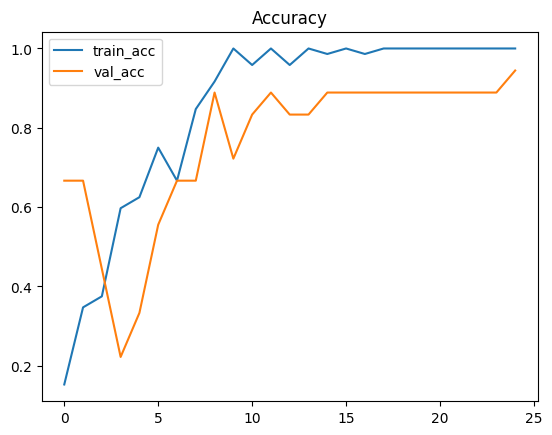

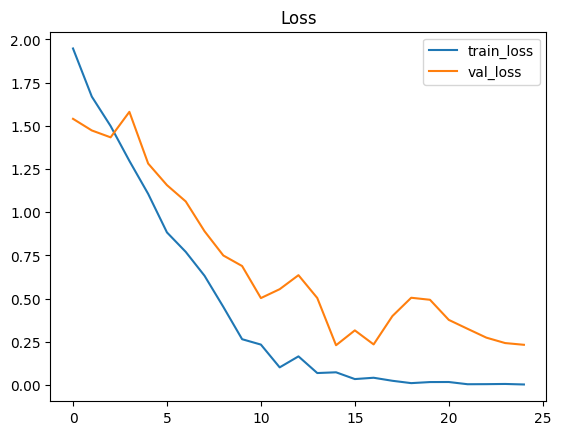

In [11]:
# Accuracy
plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.legend()
plt.title("Accuracy")
plt.show()

# Loss
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.legend()
plt.title("Loss")
plt.show()